In [1]:
""" Implementation of the nmf example using alternating projections instead of douglas-rachford."""
import numpy as np
from sklearn.decomposition import NMF
from jax import numpy as jnp
from optimize import AlternatingProjection, DouglassRachford
import projections
import matplotlib.pyplot as plt


In [4]:
### setup nmf problem    
samples=10
dimension=10
rankW = 10

Y = np.random.rand(dimension, rankW) @ np.random.rand(rankW, samples)  # generate low-rank matrix)


error 0.12257546


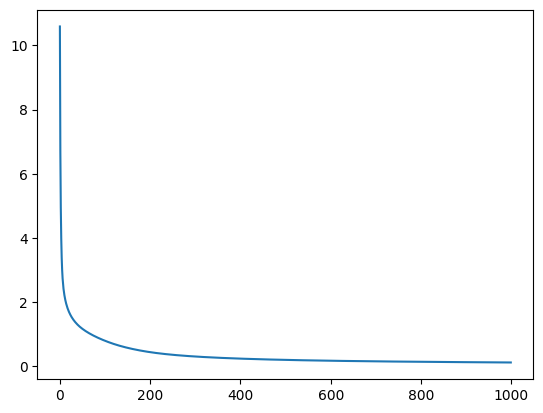

In [6]:
### nmf using alternating projections
W = np.random.rand(dimension, rankW )
X = np.random.rand(rankW, samples )
W_i = np.zeros((samples,dimension, rankW))
AP = AlternatingProjection([projections.pos], [projections.bilinearMatrix])
### perform nmf
norm = []
for iter in range(1000):
    norm.append(np.linalg.norm( W @ X - Y))
    W_i = np.zeros((samples,dimension, rankW))
    for k in range(samples):
         x, w, y = AP.step_layer(X[:,k],W, Y[:,k])
         X[:,k] = x        
         W = W + (1/(k+1))*(w - W)
plt.plot(norm)
print("error", np.linalg.norm(W @ X - Y))

error 1.8749871e-06


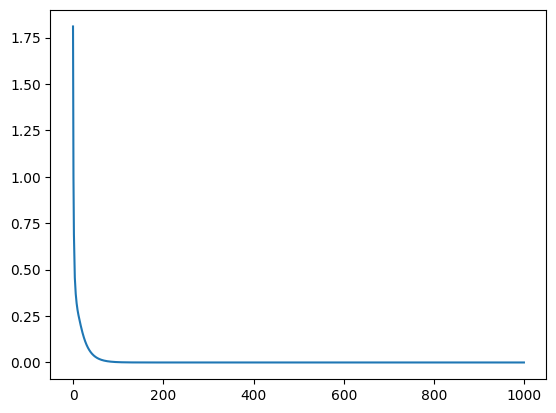

In [4]:
### nmf using douglas-rachford

W = np.random.rand(dimension, rankW )
X = np.random.rand(rankW, samples )
W_i = np.zeros((samples,dimension, rankW))
DR = DouglassRachford([projections.pos], [projections.bilinearMatrix])
### perform nmf
norm = []
for iter in range(1000):
    norm.append(np.linalg.norm( W @ X - Y))
    W_i = np.zeros((samples,dimension, rankW))
    for k in range(samples):
         x, w, y = DR.step_layer(X[:,k],W, Y[:,k])
         X[:,k] = x        
         W = W + (1/(k+1))*(w - W)
plt.plot(norm)
print("error", np.linalg.norm(W @ X - Y))